# 04 — Road and lane segmentation

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## From annotation polygons to training masks

ZOD road annotations are geometric objects, while a segmentation network needs
one value per output pixel. I scale polygon vertices into the training image,
rasterize each class independently, and keep overlap. I then validate that the
mask contains only 0/1 and that neither channel is unexpectedly empty.

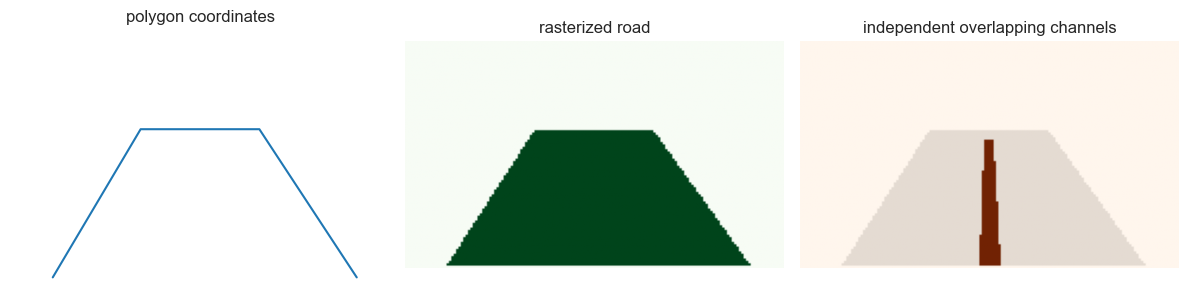

In [2]:
from matplotlib.path import Path as PolygonPath
def rasterize_polygon(vertices,height,width):
    yy,xx=np.mgrid[:height,:width]
    points=np.c_[xx.ravel()+.5,yy.ravel()+.5]
    return PolygonPath(np.asarray(vertices)).contains_points(points).reshape(height,width)

H,W=96,160
road_poly=np.array([[18,95],[55,38],[105,38],[146,95]])
lane_poly=np.array([[76,95],[78,42],[82,42],[85,95]])
road_mask=rasterize_polygon(road_poly,H,W)
lane_mask=rasterize_polygon(lane_poly,H,W) & road_mask
target=np.stack([road_mask,lane_mask]).astype(np.float32)
assert set(np.unique(target)) <= {0.,1.}
fig,ax=plt.subplots(1,3,figsize=(12,3)); ax[0].plot(*road_poly.T); ax[0].invert_yaxis(); ax[0].set_title('polygon coordinates')
ax[1].imshow(target[0],cmap='Greens'); ax[1].set_title('rasterized road')
ax[2].imshow(target[0],cmap='Greys'); ax[2].imshow(target[1],cmap='Oranges',alpha=.9); ax[2].set_title('independent overlapping channels')
for a in ax: a.set_xlim(0,W); a.set_ylim(H,0); a.axis('off')
plt.tight_layout(); plt.show()

## Resize rules are different for images and labels

Bilinear interpolation is appropriate for RGB because intensity is continuous.
It is wrong for categorical masks because it invents intermediate classes.
Nearest-neighbor interpolation preserves the discrete label set. Paired spatial
augmentation must apply the same sampled transform to image and mask; color
augmentation must touch only the image.

nearest values: [0.0, 1.0]
bilinear unique count: 10 range: (0.0, 1.0)


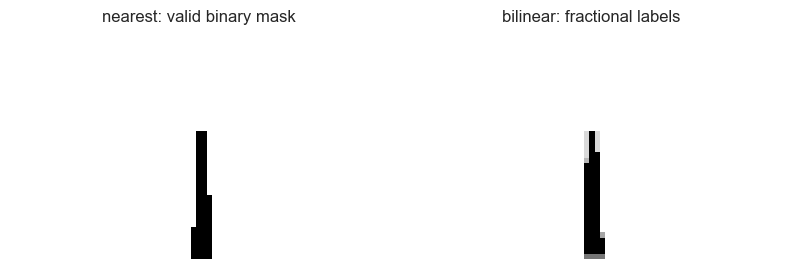

In [3]:
small=torch.from_numpy(target[1]).view(1,1,H,W)
nearest=torch.nn.functional.interpolate(small,size=(43,71),mode='nearest')
bilinear=torch.nn.functional.interpolate(small,size=(43,71),mode='bilinear',align_corners=False)
print('nearest values:',torch.unique(nearest).tolist())
print('bilinear unique count:',len(torch.unique(bilinear)),'range:',(float(bilinear.min()),float(bilinear.max())))
fig,ax=plt.subplots(1,2,figsize=(8,3)); ax[0].imshow(nearest[0,0]); ax[0].set_title('nearest: valid binary mask')
ax[1].imshow(bilinear[0,0]); ax[1].set_title('bilinear: fractional labels')
for a in ax:a.axis('off')
plt.tight_layout(); plt.show()

## A batch before it enters the network

The image tensor is channel-first floating point and normalized with the same
statistics used by the pretrained encoder. The target is not normalized. I
check shapes and ranges at the DataLoader boundary because a silent HWC/CHW or
0-255/0-1 mistake can make every later experiment meaningless.

In [4]:
rng=np.random.default_rng(11)
rgb=rng.integers(0,256,size=(H,W,3),dtype=np.uint8)
image=torch.from_numpy(rgb).permute(2,0,1).float()/255
mean=torch.tensor([.485,.456,.406])[:,None,None]; std=torch.tensor([.229,.224,.225])[:,None,None]
normalized=(image-mean)/std
batch_image=normalized.unsqueeze(0); batch_target=torch.from_numpy(target).unsqueeze(0)
print('image',tuple(batch_image.shape),batch_image.dtype,'range',tuple(round(float(x),2) for x in (batch_image.min(),batch_image.max())))
print('target',tuple(batch_target.shape),batch_target.dtype,'positive fractions',batch_target.mean((0,2,3)).tolist())

image (1, 3, 96, 160) torch.float32 range (-2.12, 2.64)
target (1, 2, 96, 160) torch.float32 positive fractions [0.3303385376930237, 0.0224609375]


## Threshold selection is part of validation

The sigmoid converts logits to probabilities, but 0.5 is not automatically the
best operating point for an imbalanced thin class. I sweep road and lane
thresholds on validation only, freeze the pair, and reuse it unchanged for the
sealed test. This tiny example shows the mechanism rather than reproducing the
private validation predictions.

,threshold,F1,TP,FP,FN
0,0.10,0.727,4,3,0
1,0.15,0.800,4,2,0
2,0.20,0.800,4,2,0
3,0.25,0.800,4,2,0
4,0.30,0.800,4,2,0
5,0.35,0.750,3,1,1
6,0.40,0.750,3,1,1
7,0.45,0.750,3,1,1
8,0.50,0.857,3,0,1
9,0.55,0.857,3,0,1


validation-selected threshold: 0.5


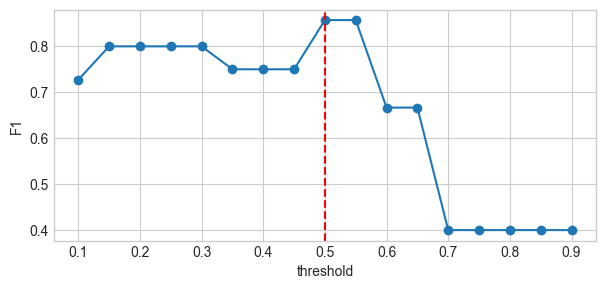

In [5]:
y=np.array([0,0,0,0,1,1,1,1]); p=np.array([.05,.12,.33,.48,.31,.55,.67,.91])
rows=[]
for threshold in np.linspace(.1,.9,17):
    pred=p>=threshold; tp=(pred & (y==1)).sum(); fp=(pred & (y==0)).sum(); fn=((~pred)&(y==1)).sum()
    f1=2*tp/max(2*tp+fp+fn,1); rows.append((threshold,f1,tp,fp,fn))
curve=pd.DataFrame(rows,columns=['threshold','F1','TP','FP','FN'])
best=curve.iloc[curve.F1.argmax()]
display(curve.round(3)); print('validation-selected threshold:',best.threshold)
plt.figure(figsize=(7,3)); plt.plot(curve.threshold,curve.F1,'o-'); plt.axvline(best.threshold,color='red',ls='--'); plt.xlabel('threshold'); plt.ylabel('F1'); plt.show()

## Learning objectives and sample contract

I want to understand label topology, preprocessing, weighted multilabel loss,
encoder–decoder shapes, thin-structure metrics, threshold calibration, and why
the largest model is not promoted.

| Tensor | Shape | Meaning |
|---|---:|---|
| image | $B\times3\times288\times512$ | ImageNet-normalized RGB |
| target | $B\times2\times288\times512$ | binary road and lane masks |
| logits | $B\times2\times288\times512$ | unconstrained model scores |
| probability | same | $p=\sigma(\ell)$ independently per channel |

Training augmentation applies the same horizontal flip to image and masks,
but color jitter only to RGB. Images use bilinear resize; discrete masks use
nearest-neighbor resize to avoid inventing fractional labels.

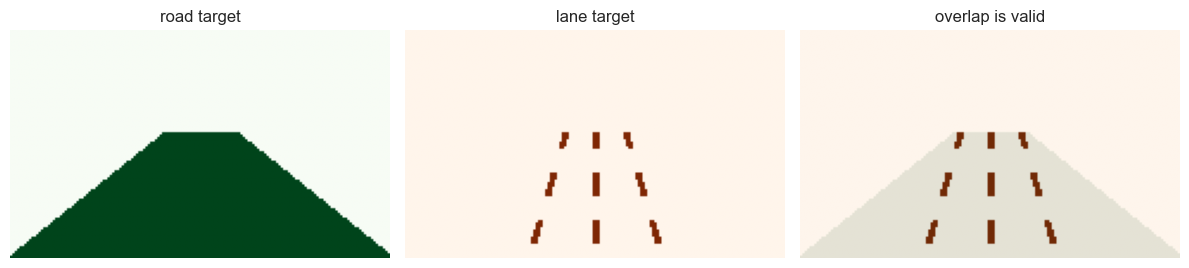

In [6]:
# Synthetic overlapping labels: lane pixels are also valid road pixels.
H,W=96,160
yy,xx=np.mgrid[:H,:W]
road=(yy > 42 + .002*(xx-80)**2) & (np.abs(xx-80) < (yy-30)*1.25)
lane=np.zeros((H,W),bool)
for offset in (-28,0,28):
    center=80 + offset*(yy/95)
    lane |= road & (np.abs(xx-center)<1.4) & ((yy//10)%2==0)
fig,ax=plt.subplots(1,3,figsize=(12,3.3))
ax[0].imshow(road,cmap='Greens'); ax[0].set_title('road target')
ax[1].imshow(lane,cmap='Oranges'); ax[1].set_title('lane target')
ax[2].imshow(road,cmap='Greens'); ax[2].imshow(lane,cmap='Oranges',alpha=.9); ax[2].set_title('overlap is valid')
for a in ax:a.axis('off')
plt.tight_layout(); plt.show()

## Why this is multilabel segmentation

A lane marking lies on the ego road, so road and lane labels overlap. A two-class
softmax would incorrectly force mutual exclusion. The model instead emits two
independent logits and uses weighted binary cross entropy. Lane positives receive
a larger weight because they occupy very few pixels.

For channel $c$ and pixel $q$,

\[
\mathcal L_{BCE}=-\frac1N\sum_{q,c}
\left[w_c^+ y_{qc}\log\sigma(\ell_{qc})+
(1-y_{qc})\log(1-\sigma(\ell_{qc}))\right],
\]

with $(w^+_{road},w^+_{lane})=(1.5,12)$. The preregistered experiment uses no
Dice-loss term; validation in the source study favored weighted BCE alone.

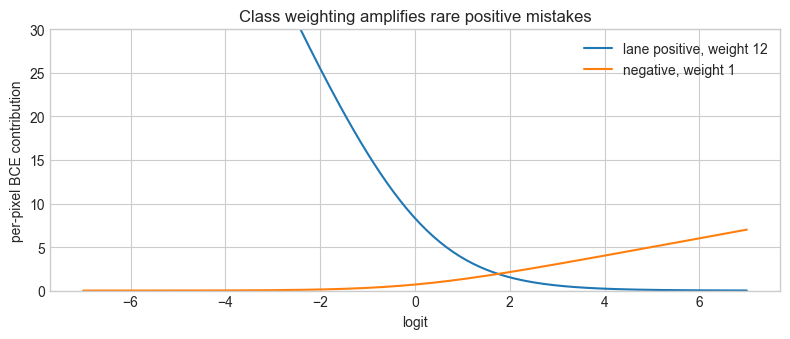

In [7]:
logits=torch.linspace(-7,7,200)
positive_loss=-12*torch.log(torch.sigmoid(logits))
negative_loss=-torch.log(1-torch.sigmoid(logits))
plt.figure(figsize=(8,3.5)); plt.plot(logits,positive_loss,label='lane positive, weight 12')
plt.plot(logits,negative_loss,label='negative, weight 1'); plt.ylim(0,30)
plt.xlabel('logit'); plt.ylabel('per-pixel BCE contribution'); plt.legend()
plt.title('Class weighting amplifies rare positive mistakes'); plt.tight_layout(); plt.show()

## Strict versus tolerant thin-line metrics

For a one-pixel structure, a one-pixel translation can make strict intersection
almost zero. Tolerant precision matches predictions against a dilated target;
tolerant recall matches targets against a dilated prediction. The radius is
three pixels at 512×288.

\[
P_{tol}=\frac{|P\cap D_r(Y)|}{|P|},\qquad
R_{tol}=\frac{|Y\cap D_r(P)|}{|Y|},\qquad
F1_{tol}=\frac{2P_{tol}R_{tol}}{P_{tol}+R_{tol}}.
\]

Strict $IoU=TP/(TP+FP+FN)$ remains visible so an excessively thick prediction
cannot hide behind the tolerance radius.

strict IoU=0.000, tolerant F1=1.000


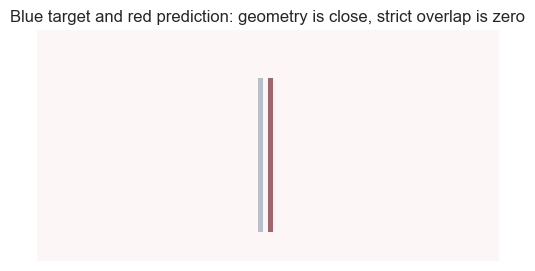

In [8]:
from torch.nn import functional as F
H,W = 48,96
target = torch.zeros(1,1,H,W); prediction = torch.zeros_like(target)
target[:,:,10:42,46] = 1
prediction[:,:,10:42,48] = 1  # correct shape, two-pixel offset
intersection = (target*prediction).sum()
strict_iou = intersection / ((target+prediction)>0).sum()
radius=3; kernel=2*radius+1
dilated_target=F.max_pool2d(target,kernel,1,radius)
dilated_prediction=F.max_pool2d(prediction,kernel,1,radius)
precision=(prediction*dilated_target).sum()/prediction.sum()
recall=(target*dilated_prediction).sum()/target.sum()
tolerant_f1=2*precision*recall/(precision+recall)
print(f"strict IoU={strict_iou:.3f}, tolerant F1={tolerant_f1:.3f}")
plt.figure(figsize=(8,3));
plt.imshow(target[0,0], cmap='Blues', alpha=.7); plt.imshow(prediction[0,0], cmap='Reds', alpha=.6)
plt.title('Blue target and red prediction: geometry is close, strict overlap is zero'); plt.axis('off'); plt.show()

## DeepLab reference and U-Net architecture

My earlier standalone study used MobileNetV3–DeepLabV3. Atrous convolutions
provide broad semantic context, but this compact decoder does not expose a full
symmetric skip hierarchy. I use it here as the reference for the U-Net study.

The replacement uses a pretrained ResNet-18 encoder:

| Stage | Channels | Spatial size for 288×512 |
|---|---:|---:|
| stem skip | 64 | $144\times256$ |
| layer1 skip | 64 | $72\times128$ |
| layer2 skip | 128 | $36\times64$ |
| layer3 skip | 256 | $18\times32$ |
| layer4 bottleneck | 512 | $9\times16$ |

The decoder bilinearly upsamples, concatenates the matching encoder skip, and
applies two $3\times3$ convolution–batchnorm–ReLU blocks at each level.

## Why U-Net helps

Deep encoders build semantics but reduce spatial resolution. U-Net concatenates
high-resolution encoder features into each decoder level, allowing the model to
recover exact boundaries and narrow lane markings. The result is especially
clear in strict lane IoU: 0.187 for DeepLab versus 0.466 for U-Net.

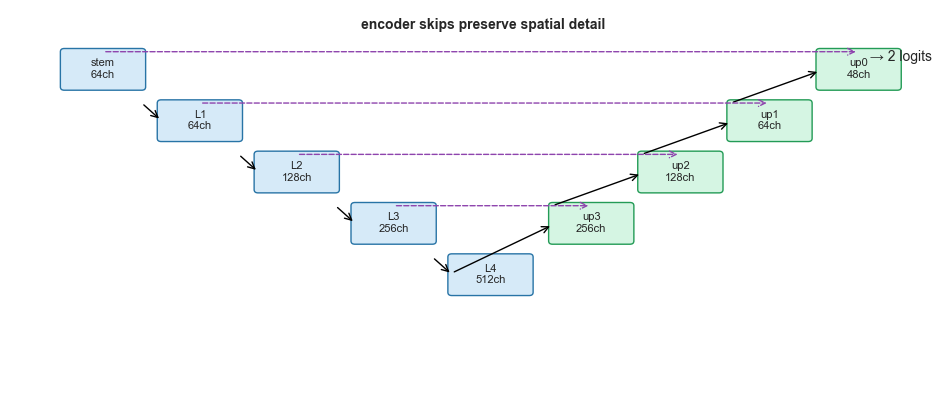

In [9]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig,ax=plt.subplots(figsize=(12,5)); ax.set_xlim(0,12); ax.set_ylim(0,6); ax.axis('off')
levels=[('stem',64,4.8),('L1',64,4.0),('L2',128,3.2),('L3',256,2.4),('L4',512,1.6)]
for i,(name,ch,y) in enumerate(levels):
    x=.7+i*1.25; ax.add_patch(FancyBboxPatch((x,y),1,.55,boxstyle='round,pad=.05',fc='#d6eaf8',ec='#2874a6'))
    ax.text(x+.5,y+.28,f'{name}\n{ch}ch',ha='center',va='center',fontsize=8)
    if i: ax.add_patch(FancyArrowPatch((x-.25,y+.55),(x,y+.28),arrowstyle='->',mutation_scale=12))
decoder=[('up3',256,2.4),('up2',128,3.2),('up1',64,4.0),('up0',48,4.8)]
for i,(name,ch,y) in enumerate(decoder):
    x=7.0+i*1.15; ax.add_patch(FancyBboxPatch((x,y),1,.55,boxstyle='round,pad=.05',fc='#d5f5e3',ec='#239b56'))
    ax.text(x+.5,y+.28,f'{name}\n{ch}ch',ha='center',va='center',fontsize=8)
    if i: ax.add_patch(FancyArrowPatch((x-1.15,y-.25),(x,y+.25),arrowstyle='->',mutation_scale=12))
for i in range(4):
    sx=.7+(3-i)*1.25+.5; dx=7.0+i*1.15+.5; y=2.4+i*.8
    ax.add_patch(FancyArrowPatch((sx,y+.55),(dx,y+.55),arrowstyle='->',ls='--',color='#8e44ad',mutation_scale=12))
ax.add_patch(FancyArrowPatch((5.7,1.9),(7,2.65),arrowstyle='->',mutation_scale=12))
ax.text(6.1,5.7,'encoder skips preserve spatial detail',ha='center',weight='bold')
ax.text(11.1,5.2,'→ 2 logits',fontsize=10); plt.show()

In [10]:
from zod_driveformer.segmentation.models import build_segmentation_model
models = {
    'U-Net': build_segmentation_model('resnet18_unet', pretrained=False),
    'Fourier U-Net': build_segmentation_model('resnet18_fourier_unet', pretrained=False,
        config={'spectral_modes_height':5,'spectral_modes_width':8,'spectral_blocks':2}),
}
for name, model in models.items():
    image=torch.zeros(1,3,96,160)
    with torch.no_grad(): output=model(image)
    print(name, f"{sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters", "output", tuple(output.shape))
del models

U-Net 14.37M parameters output (1, 2, 96, 160)
Fourier U-Net 56.84M parameters output (1, 2, 96, 160)


## What the Fourier bottleneck tests

The Fourier variant keeps the same encoder, skips, decoder, data, and loss, but
adds global low-frequency mixing at the 9×16 bottleneck. This is a controlled
test of whether global spectral context adds value after U-Net already supplies
local multiscale evidence.

Each of two residual blocks computes

\[
u' = u+\operatorname{GELU}(\operatorname{GN}(
\mathcal F^{-1}(R\mathcal F(u))+W_{1\times1}u)).
\]

It retains 5 vertical and 8 horizontal modes with separate learned weights for
positive and negative vertical frequencies. Complex weights explain much of
the increase from 14.4M to 56.8M parameters. This candidate trained in FP32
because PyTorch gradient scaling cannot unscale `ComplexFloat` gradients; the
real-valued models used AMP.

## Training, selection, and threshold calibration

All three architectures use AdamW, cosine learning-rate decay, three seeds,
batch size 8, and at most 24 epochs. The pretrained encoder is frozen for the
first two epochs. The best epoch maximizes validation

\[
S=\tfrac12(IoU_{road}+F1^{tol}_{lane}).
\]

After checkpoint selection, road and lane thresholds are independently chosen
from $\{0.30,0.35,\ldots,0.75\}$ on validation only. The decomposable score
allows road threshold to maximize road IoU and lane threshold to maximize lane
tolerant F1. Test masks influence neither choice.

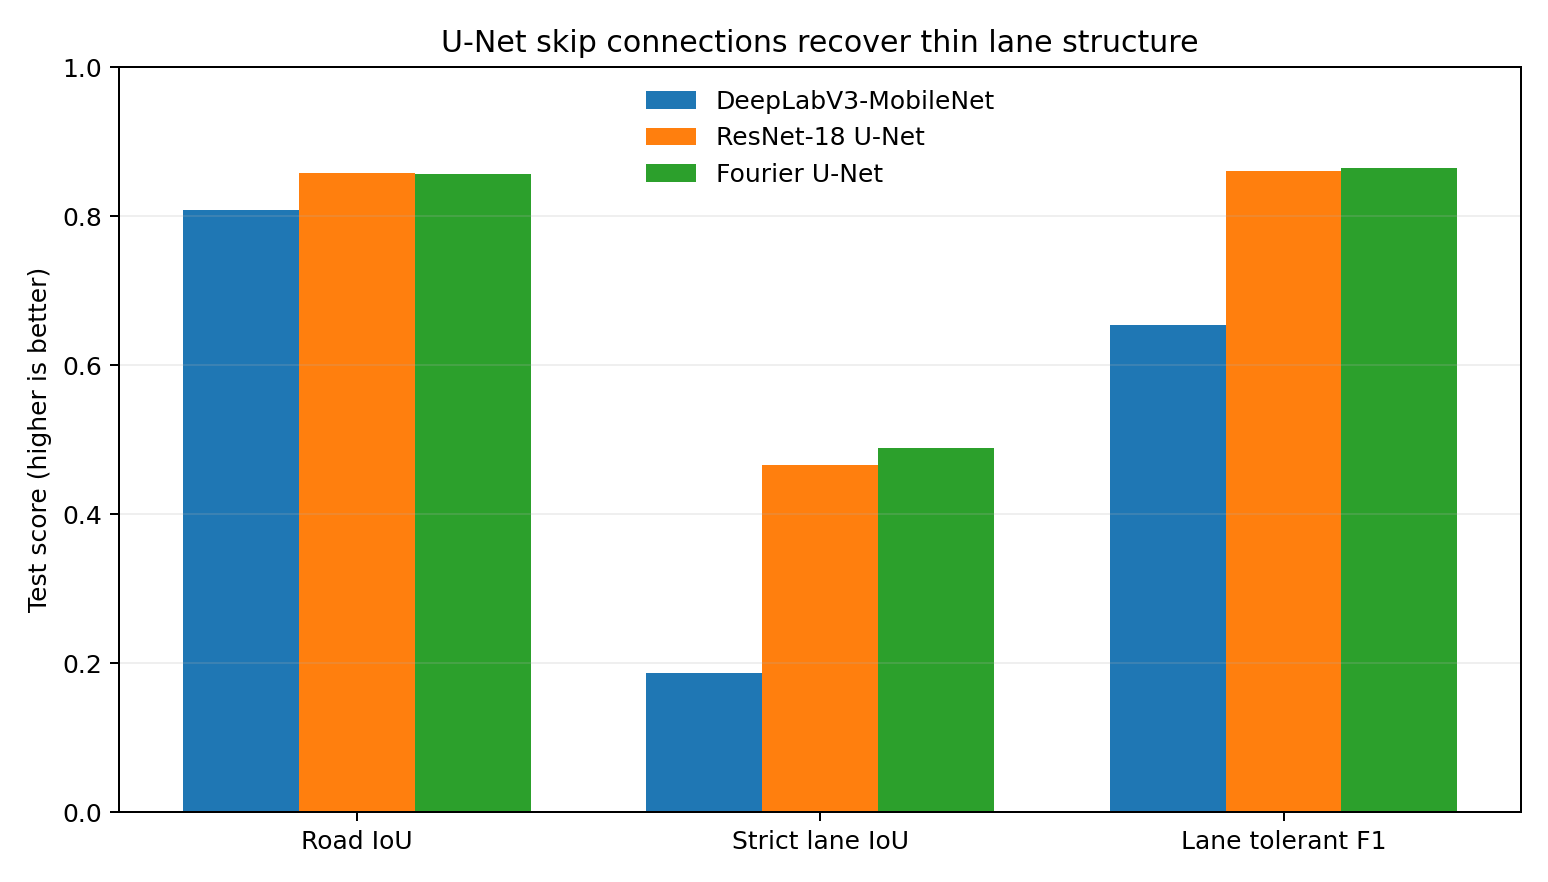

In [11]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'reports/figures/segmentation_test_metrics.png')))

## Reading the predicted masks

Cyan is the thresholded road channel and magenta is the thresholded lane
channel. Lane pixels can lie inside road pixels, so the overlay deliberately
shows overlap rather than forcing a mutually exclusive class map. Fixed score
quantiles plus disagreement cases avoid selecting only attractive examples.
All columns use the frozen seed-2026 checkpoints.

![Segmentation model montage](../reports/figures/segmentation_model_comparison.png)

![Animated held-out segmentation cases](../reports/figures/segmentation_model_comparison.gif)

In [12]:
pair = summary["fourier_unet_minus_unet_per_image"]["delta_selection_score"]
print(f"Fourier U-Net − U-Net score: {pair['estimate']:+.4f}")
print(f"95% paired interval: [{pair['lower']:+.4f}, {pair['upper']:+.4f}]")

Fourier U-Net − U-Net score: +0.0010
95% paired interval: [-0.0072, +0.0094]


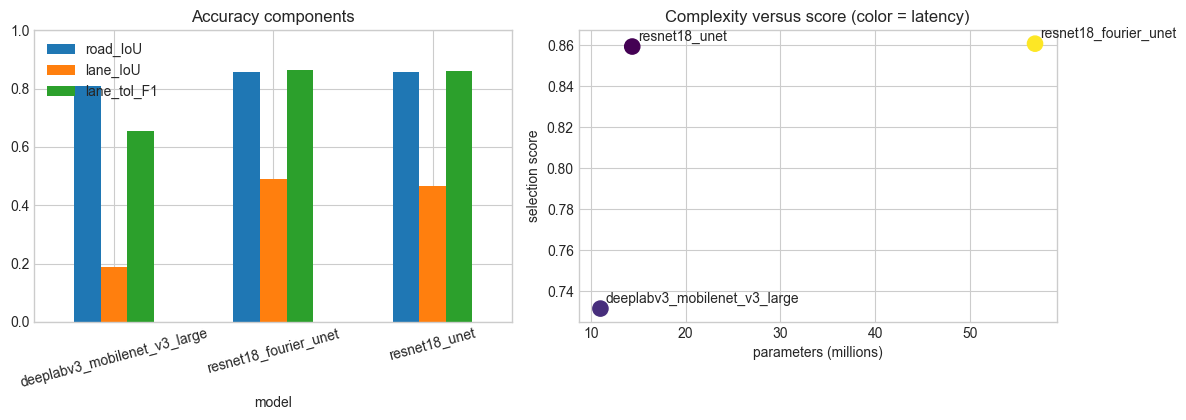

In [13]:
seg=summary['segmentation']['models']
rows=[]
for name,e in seg.items():
    m=e['global_pixel_metrics_across_seeds']
    rows.append((name,m['road_iou']['mean'],m['lane_iou']['mean'],m['lane_tolerant_f1']['mean'],
                 m['selection_score']['mean'],e['parameters']/1e6,e['latency']['batch_1_median_ms']))
frame=pd.DataFrame(rows,columns=['model','road_IoU','lane_IoU','lane_tol_F1','score','params_M','latency_ms'])
fig,ax=plt.subplots(1,2,figsize=(12,4.3))
frame.set_index('model')[['road_IoU','lane_IoU','lane_tol_F1']].plot.bar(ax=ax[0],rot=15)
ax[0].set_ylim(0,1); ax[0].set_title('Accuracy components')
ax[1].scatter(frame.params_M,frame.score,s=120,c=frame.latency_ms,cmap='viridis')
for row in frame.itertuples(): ax[1].annotate(row.model,(row.params_M,row.score),xytext=(4,4),textcoords='offset points')
ax[1].set_xlabel('parameters (millions)'); ax[1].set_ylabel('selection score'); ax[1].set_title('Complexity versus score (color = latency)')
plt.tight_layout(); plt.show()

## Model choice

Fourier U-Net has the highest raw strict lane IoU and score, but its direct
score improvement over ordinary U-Net is only +0.0010 with interval
[−0.0072,+0.0094]. That is not evidence of a reliable win. Both U-Nets improve
the original DeepLab family reliably by about +0.136 score. Because Fourier
U-Net uses 56.8M rather than 14.4M parameters and is slower, ordinary U-Net is
the promoted model.

### Check my understanding

1. Use sigmoid, not channel softmax, because road and lane overlap.
2. Use nearest-neighbor mask resize because labels are categorical.
3. Keep strict IoU beside tolerant F1 so tolerance cannot reward thick masks.
4. Select thresholds on validation; touching test thresholds invalidates the test.
5. “Fourier has the highest decimal” is not “Fourier is demonstrably better.”